# Rhode Island bridges -- first look at the raw data

Exploring `data/raw/RI25.csv` (the FHWA National Bridge Inventory extract) before
any cleaning, to see its shape, its missing data, and the quirks the cleaning step
will need to handle.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE = "#2a78d6"

# Read as text first: don't let pandas coerce anything (drop leading zeros, turn
# "N" into NaN) before we've looked at it.
raw = pd.read_csv("../data/raw/RI25.csv", dtype=str)
raw.shape

(787, 123)

787 bridges, 123 standard NBI fields.

## Columns and types

In [2]:
raw.head()

,STATE_CODE_001,STRUCTURE_NUMBER_008,RECORD_TYPE_005A,ROUTE_PREFIX_005B,SERVICE_LEVEL_005C,ROUTE_NUMBER_005D,DIRECTION_005E,HIGHWAY_DISTRICT_002,COUNTY_CODE_003,PLACE_CODE_004,...,BRIDGE_LEN_IND_112,SCOUR_CRITICAL_113,FUTURE_ADT_114,YEAR_OF_FUTURE_ADT_115,MIN_NAV_CLR_MT_116,FED_AGENCY,SUBMITTED_BY,BRIDGE_CONDITION,LOWEST_RATING,DECK_AREA
0,44,1RI0668,1,8,0,00000,0,00,005,49960,...,Y,5,1550,2035,NaN,Y,73,F,6,435.54
1,44,1RI1400,1,8,0,00000,0,00,005,49960,...,Y,5,2500,2035,NaN,Y,73,F,6,3197.6
2,44,000000000000010,1,2,1,00001,1,04,007,19180,...,Y,4,19732,2036,NaN,N,44,F,5,799.75
3,44,000000000000020,1,3,1,00113,0,04,003,74300,...,Y,N,40942,2036,0,N,44,P,4,619.97
4,44,000000000000060,1,2,1,00001,0,04,009,51580,...,Y,3,9600,2036,NaN,N,44,F,5,151.13


In [3]:
raw.columns.tolist()

['STATE_CODE_001',
 'STRUCTURE_NUMBER_008',
 'RECORD_TYPE_005A',
 'ROUTE_PREFIX_005B',
 'SERVICE_LEVEL_005C',
 'ROUTE_NUMBER_005D',
 'DIRECTION_005E',
 'HIGHWAY_DISTRICT_002',
 'COUNTY_CODE_003',
 'PLACE_CODE_004',
 'FEATURES_DESC_006A',
 'CRITICAL_FACILITY_006B',
 'FACILITY_CARRIED_007',
 'LOCATION_009',
 'MIN_VERT_CLR_010',
 'KILOPOINT_011',
 'BASE_HWY_NETWORK_012',
 'LRS_INV_ROUTE_013A',
 'SUBROUTE_NO_013B',
 'LAT_016',
 'LONG_017',
 'DETOUR_KILOS_019',
 'TOLL_020',
 'MAINTENANCE_021',
 'OWNER_022',
 'FUNCTIONAL_CLASS_026',
 'YEAR_BUILT_027',
 'TRAFFIC_LANES_ON_028A',
 'TRAFFIC_LANES_UND_028B',
 'ADT_029',
 'YEAR_ADT_030',
 'DESIGN_LOAD_031',
 'APPR_WIDTH_MT_032',
 'MEDIAN_CODE_033',
 'DEGREES_SKEW_034',
 'STRUCTURE_FLARED_035',
 'RAILINGS_036A',
 'TRANSITIONS_036B',
 'APPR_RAIL_036C',
 'APPR_RAIL_END_036D',
 'HISTORY_037',
 'NAVIGATION_038',
 'NAV_VERT_CLR_MT_039',
 'NAV_HORR_CLR_MT_040',
 'OPEN_CLOSED_POSTED_041',
 'SERVICE_ON_042A',
 'SERVICE_UND_042B',
 'STRUCTURE_KIND_043A',
 '

The full NBI record: condition ratings, traffic, geometry, inspection history, admin codes.

In [4]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787 entries, 0 to 786
Columns: 123 entries, STATE_CODE_001 to DECK_AREA
dtypes: object(123)
memory usage: 756.4+ KB


All `object` -- everything came in as text. Columns are converted one at a time after they're checked.

In [5]:
key_num = ["LOWEST_RATING", "ADT_029", "DECK_AREA",
           "STRUCTURE_LEN_MT_049", "DECK_WIDTH_MT_052", "YEAR_BUILT_027"]
raw[key_num].apply(pd.to_numeric, errors="coerce").describe().round(1)

,LOWEST_RATING,ADT_029,DECK_AREA,STRUCTURE_LEN_MT_049,DECK_WIDTH_MT_052,YEAR_BUILT_027
count,787.0,787.0,787.0,787.0,787.0,787.0
mean,5.7,20147.3,943.7,53.9,17.1,1970.6
std,1.1,30552.4,3061.3,165.8,12.1,36.4
min,2.0,0.0,37.4,6.1,0.0,1810.0
25%,5.0,3417.0,211.2,14.6,11.8,1955.5
50%,6.0,10909.0,465.0,27.7,14.8,1967.0
75%,6.0,22384.5,891.8,50.0,19.5,2003.0
max,8.0,236230.0,56568.6,3428.4,189.6,2026.0


`ADT_029` has a minimum of 0 (looked at below). `LOWEST_RATING` runs 2-8. Deck area spans a wide range -- it drives cost.

## Missing values by column

In [6]:
na = raw.isna().sum()
na[na > 0].sort_values(ascending=False)

CRITICAL_FACILITY_006B     787
LRS_INV_ROUTE_013A         786
TEMP_STRUCTURE_103         784
OTHER_STATE_PCNT_098B      780
OTHER_STATE_CODE_098A      780
FRACTURE_LAST_DATE_093A    751
PIER_PROTECTION_111        712
UNDWATER_LAST_DATE_093B    699
MIN_NAV_CLR_MT_116         658
SPEC_LAST_DATE_093C        622
WORK_PROPOSED_075A          70
WORK_DONE_BY_075B           70
IMP_LEN_MT_076              65
SUBROUTE_NO_013B            25
YEAR_RECONSTRUCTED_106       2
BASE_HWY_NETWORK_012         1
dtype: int64

Only a few columns have true blanks, none of them ones the model needs. Two columns
carry "missing" as a sentinel instead of a blank: the condition fields use `"N"`
(not applicable), and `ADT_029` uses `0`. Both are handled below.

## Types of bridge

In [7]:
kind = raw["STRUCTURE_KIND_043A"].value_counts(dropna=False)   # 1 concrete, 3 steel, 5 prestressed concrete, ...
culverts = (raw["CULVERT_COND_062"] != "N").sum()
on_nhs = (raw["NATIONAL_NETWORK_110"] == "1").sum()

print(kind.to_string())
print("\nculverts (rated on CULVERT_COND_062):", culverts)
print("on the National Highway System        :", on_nhs, "of", len(raw))

STRUCTURE_KIND_043A
3    327
5    163
1    155
4     85
2     19
8     17
7      9
6      6
0      4
9      2

culverts (rated on CULVERT_COND_062): 44
on the National Highway System        : 191 of 787


In [8]:
raw["FUNCTIONAL_CLASS_026"].value_counts(dropna=False)   # road class the bridge sits on

FUNCTIONAL_CLASS_026
16    142
14    131
11    129
12    124
17     87
19     59
09     32
07     22
08     22
02     16
01     14
06      9
Name: count, dtype: int64

In [9]:
raw["BRIDGE_CONDITION"].value_counts().rename({"G": "Good", "F": "Fair", "P": "Poor"})

BRIDGE_CONDITION
Fair    481
Good    196
Poor    110
Name: count, dtype: int64

FHWA's own Good / Fair / Poor label. 14% Poor is the pool the investment plan is triaging.

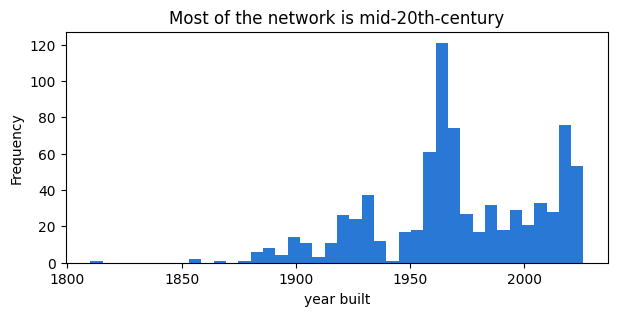

In [10]:
yb = pd.to_numeric(raw["YEAR_BUILT_027"], errors="coerce")
yb.plot(kind="hist", bins=40, color=BLUE, figsize=(7, 3))
plt.xlabel("year built")
plt.title("Most of the network is mid-20th-century")
plt.show()

## Condition ratings and the `"N"` values

In [11]:
cond = ["DECK_COND_058", "SUPERSTRUCTURE_COND_059", "SUBSTRUCTURE_COND_060", "CULVERT_COND_062"]
pd.DataFrame({c: raw[c].value_counts(dropna=False) for c in cond}).fillna(0).astype(int).sort_index()

,DECK_COND_058,SUPERSTRUCTURE_COND_059,SUBSTRUCTURE_COND_060,CULVERT_COND_062
2,1,5,1,0
3,1,15,2,0
4,22,58,44,2
5,91,203,138,3
6,219,199,301,23
7,233,158,206,15
8,88,103,51,1
9,7,2,0,0
N,125,44,44,743


`CULVERT_COND_062` is `"N"` for all but 44 bridges; `DECK_COND_058` is `"N"` for
125. A culvert has no deck/superstructure/substructure, so it's rated on the
culvert field and shows `"N"` on the other three.

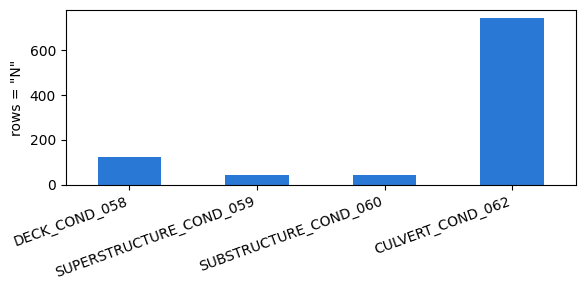

In [12]:
(raw[cond] == "N").sum().plot(kind="bar", color=BLUE, figsize=(6, 3))
plt.ylabel('rows = "N"')
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [13]:
num = raw[cond].apply(pd.to_numeric, errors="coerce")           # "N" -> NaN
worst = num.min(axis=1)                                         # worst rated component
official = pd.to_numeric(raw["LOWEST_RATING"], errors="coerce")

print("culvert-rated bridges              :", int(num["CULVERT_COND_062"].notna().sum()))
print('"N" across deck+super+substructure :', int(num[cond[:3]].isna().all(axis=1).sum()))
print("LOWEST_RATING == worst component   :", bool((worst == official).all()), "(all 787 rows)")
print("LOWEST_RATING missing              :", int(official.isna().sum()))

culvert-rated bridges              : 44
"N" across deck+super+substructure : 44
LOWEST_RATING == worst component   : True (all 787 rows)
LOWEST_RATING missing              : 0


The culvert-rated set and the `"N"`-across-the-other-three set are the same 44
bridges, and `LOWEST_RATING` already equals the worst rated component for every
row. So the cleaning step can take `LOWEST_RATING` directly rather than re-deriving
the culvert logic.

## Traffic (ADT)

In [14]:
adt = pd.to_numeric(raw["ADT_029"], errors="coerce")
print("zeros:", int((adt == 0).sum()), "  NaN:", int(adt.isna().sum()),
      "  median of positive values:", adt[adt > 0].median())

raw.loc[adt == 0, ["STRUCTURE_NUMBER_008", "FACILITY_CARRIED_007",
                   "FEATURES_DESC_006A", "YEAR_ADT_030"]]

zeros: 3   NaN: 0   median of positive values: 10926.0


,STRUCTURE_NUMBER_008,FACILITY_CARRIED_007,FEATURES_DESC_006A,YEAR_ADT_030
138,000000000003010,'SNEECH POND RD','ABBOTT RUN',2008
430,000000000006740,'TEMPLE AV','RI 10 HUNTINGTON EXPRESS',2004
769,000000000012470,'US 1 SB POST RD','CROSS MILLS STREAM',2015


Three bridges read 0 on named through-roads (one carries `US 1 SB POST RD`), each
with a traffic-survey year recorded -- missing counts entered as 0, not genuinely
unused roads.

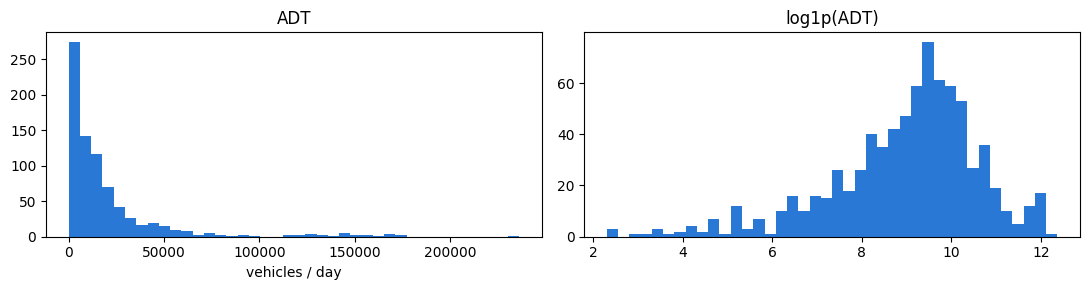

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].hist(adt[adt > 0], bins=40, color=BLUE); ax[0].set_title("ADT"); ax[0].set_xlabel("vehicles / day")
ax[1].hist(np.log1p(adt[adt > 0]), bins=40, color=BLUE); ax[1].set_title("log1p(ADT)")
plt.tight_layout()
plt.show()

Right-skewed across three orders of magnitude: a handful of interstate bridges, a long tail of local ones.

## Deck area

In [16]:
length = pd.to_numeric(raw["STRUCTURE_LEN_MT_049"], errors="coerce")
width = pd.to_numeric(raw["DECK_WIDTH_MT_052"], errors="coerce")
area = pd.to_numeric(raw["DECK_AREA"], errors="coerce")

m = width > 0
print("DECK_AREA missing:", int(area.isna().sum()), "  zero:", int((area == 0).sum()))
print("within 5% of length x width:", round((((length[m] * width[m]) - area[m]).abs() / area[m] < 0.05).mean(), 3))

DECK_AREA missing: 0   zero: 0
within 5% of length x width: 1.0


Complete, and consistent with length x width (both in metres) -- usable as-is for the cost model.

## Structure number

In [17]:
sn = raw["STRUCTURE_NUMBER_008"].str.strip()
print(sn.head(3).tolist(), "...", sn.tail(2).tolist())
print("contain a letter :", int((~sn.str.match(r"^\d+$")).sum()))
print("leading zero     :", int(sn.str.match(r"^0").sum()))
print("unique as text   :", sn.nunique())
print("unique as integer:", pd.to_numeric(sn, errors="coerce").nunique())

['1RI0668', '1RI1400', '000000000000010'] ... ['000000000015510', '00000000014280']
contain a letter : 2
leading zero     : 785
unique as text   : 787
unique as integer: 785


Mixed formats, leading zeros, two alphanumeric. Cast to integer it loses rows and collapses ids, so it stays text.

## What the cleaning step needs to do

- `LOWEST_RATING` -> `lowest_rating`: take directly (already resolves the culvert `"N"` case)
- `ADT_029` -> `adt`: replace the 3 zeros with the positive-value median, flag them
- `DECK_AREA` -> `deck_area_sqm`: take directly
- `NATIONAL_NETWORK_110` -> `is_nhs`: keep, it selects the cost rate
- `STRUCTURE_NUMBER_008` -> `structure_number`: keep as text
- drop rows with no condition rating or no deck area (none in this extract)
- keep `bridge_condition`, `year_built`, `functional_class`, `owner_code`,
  `facility_carried`, `features_desc` as labels for reading results; leave the
  other ~110 fields in the raw file

`src/data_prep.py` does exactly this and writes `data/processed/bridges.csv`.